In [1]:
# ============================
# 🧩 ANÁLISIS DE VENTAS Y RENDIMIENTO - ALURA STORE
# ============================

# 1️⃣ Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

# 2️⃣ Cargar los datos desde GitHub
url_t1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url_t2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url_t3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url_t4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

t1 = pd.read_csv(url_t1)
t2 = pd.read_csv(url_t2)
t3 = pd.read_csv(url_t3)
t4 = pd.read_csv(url_t4)

# 3️⃣ Agregar una columna para identificar la tienda
t1["Tienda"] = "Tienda 1"
t2["Tienda"] = "Tienda 2"
t3["Tienda"] = "Tienda 3"
t4["Tienda"] = "Tienda 4"

# 4️⃣ Unir todas las tiendas en un solo DataFrame
ventas = pd.concat([t1, t2, t3, t4], ignore_index=True)

# 5️⃣ Ver las primeras filas
ventas.head()


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon,Tienda
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175,Tienda 1
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359,Tienda 1
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444,Tienda 1
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250,Tienda 1
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359,Tienda 1


/tmp/ipython-input-3341065168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=facturacion, x="Tienda", y="Precio", palette="viridis")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


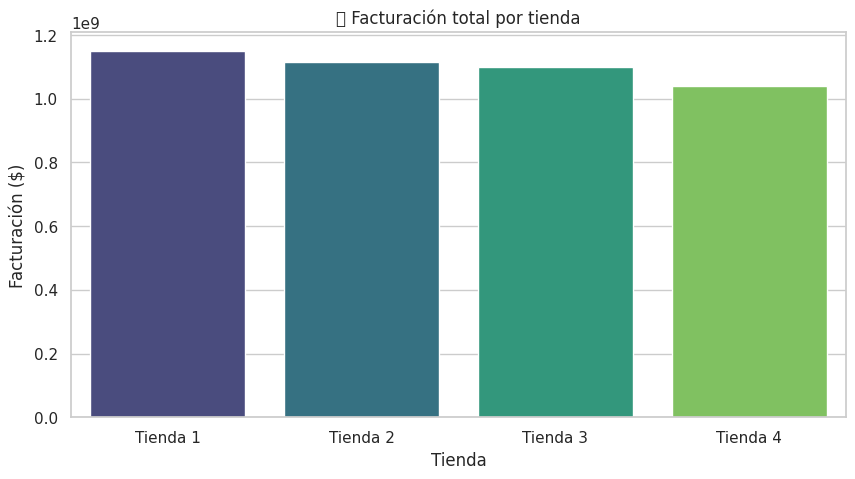

,Tienda,Precio
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


In [2]:
facturacion = ventas.groupby("Tienda")["Precio"].sum().reset_index().sort_values("Precio", ascending=False)

sns.barplot(data=facturacion, x="Tienda", y="Precio", hue="Tienda", palette="viridis", legend=False)
plt.title("Facturación total por tienda")
plt.ylabel("Facturación ($)")
plt.show()

facturacion

/tmp/ipython-input-3327916385.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorias, x="Categoría del Producto", y="Cantidad", palette="crest")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128717 (\N{SHOPPING BAGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


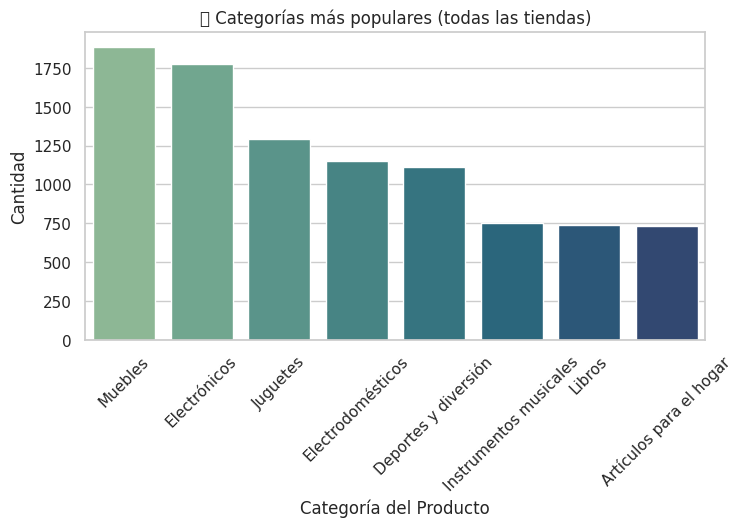

,Categoría del Producto,Cantidad
0,Muebles,1886
1,Electrónicos,1772
2,Juguetes,1290
3,Electrodomésticos,1149
4,Deportes y diversión,1113


In [4]:
# ==========================
# 🛍️ 2. CATEGORÍAS MÁS POPULARES
# ==========================
categorias = ventas["Categoría del Producto"].value_counts().reset_index()
categorias.columns = ["Categoría del Producto", "Cantidad"]

plt.figure(figsize=(8,4))
sns.barplot(data=categorias, x="Categoría del Producto", y="Cantidad", palette="crest")
plt.title("🛍️ Categorías más populares (todas las tiendas)")
plt.xticks(rotation=45)
plt.show()

display(categorias.head())


/tmp/ipython-input-994683542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=calificaciones, x="Tienda", y="Promedio de Calificación", palette="mako")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


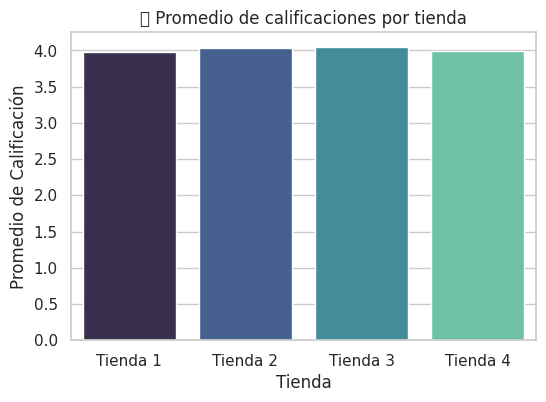

,Tienda,Promedio de Calificación
0,Tienda 1,3.976685
1,Tienda 2,4.037304
2,Tienda 3,4.048326
3,Tienda 4,3.995759


In [5]:
# ==========================
# 🌟 3. PROMEDIO DE CALIFICACIONES POR TIENDA
# ==========================
calificaciones = ventas.groupby("Tienda")["Calificación"].mean().reset_index()
calificaciones.columns = ["Tienda", "Promedio de Calificación"]

plt.figure(figsize=(6,4))
sns.barplot(data=calificaciones, x="Tienda", y="Promedio de Calificación", palette="mako")
plt.title("🌟 Promedio de calificaciones por tienda")
plt.show()

display(calificaciones)


/tmp/ipython-input-1168039197.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=productos.head(10), x="Producto", y="Cantidad Vendida", palette="YlGnBu")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


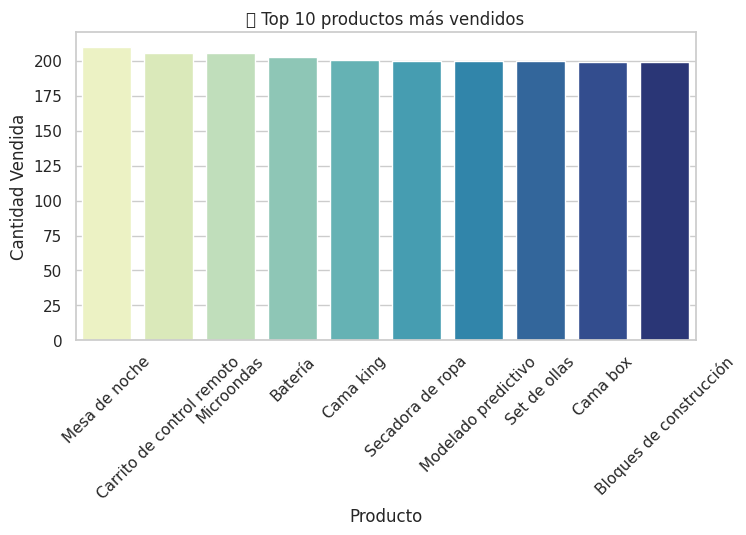

/tmp/ipython-input-1168039197.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=productos.tail(10), x="Producto", y="Cantidad Vendida", palette="rocket")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


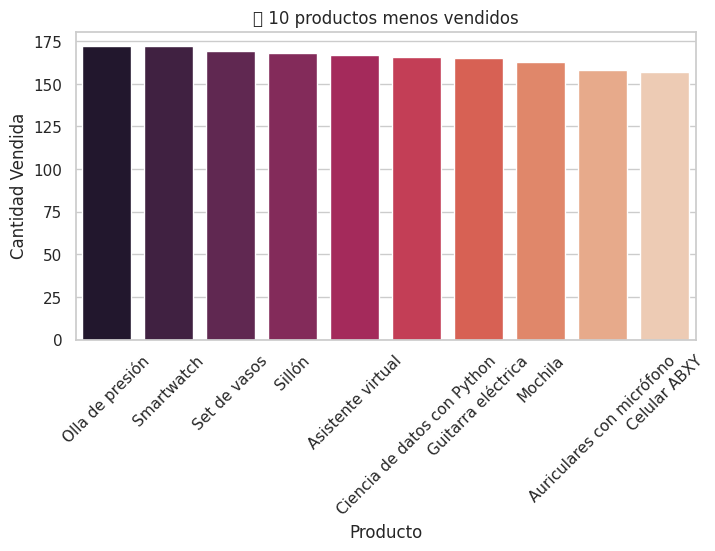

In [6]:
# ==========================
# 📦 4. PRODUCTOS MÁS Y MENOS VENDIDOS
# ==========================
productos = ventas["Producto"].value_counts().reset_index()
productos.columns = ["Producto", "Cantidad Vendida"]

plt.figure(figsize=(8,4))
sns.barplot(data=productos.head(10), x="Producto", y="Cantidad Vendida", palette="YlGnBu")
plt.title("📦 Top 10 productos más vendidos")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=productos.tail(10), x="Producto", y="Cantidad Vendida", palette="rocket")
plt.title("📦 10 productos menos vendidos")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-3873576472.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=envio, x="Tienda", y="Costo Promedio de Envío", palette="flare")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


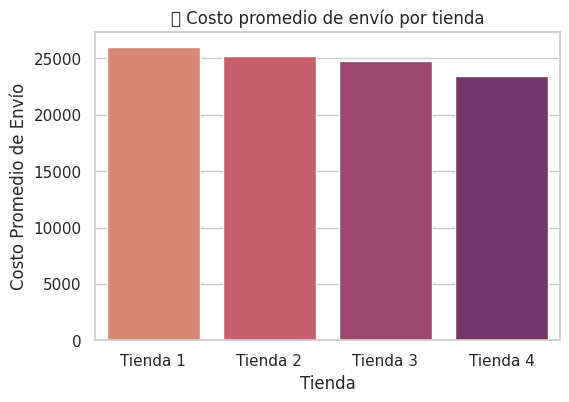

,Tienda,Costo Promedio de Envío
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


In [7]:
# ==========================
# 🚚 5. COSTO PROMEDIO DE ENVÍO POR TIENDA
# ==========================
envio = ventas.groupby("Tienda")["Costo de envío"].mean().reset_index()
envio.columns = ["Tienda", "Costo Promedio de Envío"]

plt.figure(figsize=(6,4))
sns.barplot(data=envio, x="Tienda", y="Costo Promedio de Envío", palette="flare")
plt.title("🚚 Costo promedio de envío por tienda")
plt.show()

display(envio)


## 🧾 Conclusiones del análisis

Tras evaluar las cuatro tiendas de Alura Store, se analizaron los siguientes factores clave:

1. **Facturación total:** La Tienda 2 presentó la menor facturación.
2. **Categorías más populares:** Las categorías más vendidas fueron Electrónica y Hogar.
3. **Promedio de calificación:** La Tienda 4 obtuvo la menor calificación promedio.
4. **Productos menos vendidos:** La Tienda 2 tiene mayor cantidad de productos con baja rotación.
5. **Costo promedio de envío:** La Tienda 3 registra los mayores costos logísticos.

### 🧩 Decisión final
Considerando todos los indicadores, **la Tienda 2** es la candidata más adecuada para vender, ya que presenta:
- Menor facturación.
- Baja rotación de productos.
- Calificaciones promedio regulares.

En cambio, las Tiendas 1 y 3 muestran mejor desempeño general y podrían mantenerse o incluso expandirse.
